# Notebook 02: TF-IDF Vectorization & PCA Dimensionality Reduction

This notebook handles:
1. Loading cleaned reviews from Notebook 01
2. Converting reviews to TF-IDF vectors
3. Running PCA experiments (components: 20, 50, 100, 200)
4. Analyzing variance retention
5. Running K-Means clustering
6. Evaluating cluster quality with Silhouette Score

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Get the absolute path to the directory where THIS script is located
# Then go to the 'src' folder relative to that
current_dir = os.path.dirname(os.path.abspath('')) # Use os.getcwd() if in a Notebook
src_path = os.path.join(current_dir, 'src')

if src_path not in sys.path:
    sys.path.insert(0, src_path)

from vectorize import vectorize_reviews
from clustering import run_pca_experiments, run_kmeans, analyze_clusters

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## Phase 1: Load Preprocessed Data

In [17]:
# Load cleaned reviews
cleaned_df = pd.read_csv('./outputs/cleaned_reviews.csv')
cleaned_reviews = cleaned_df['cleaned_review'].values
real_labels = cleaned_df['label'].values

print(f"Loaded {len(cleaned_reviews)} cleaned reviews")
print(f"Loaded {len(real_labels)} real labels")
print(f"Label distribution: {np.bincount(real_labels)}")

Loaded 50000 cleaned reviews
Loaded 50000 real labels
Label distribution: [25000 25000]


## Phase 2: TF-IDF Vectorization

In [18]:
# Apply TF-IDF vectorization
print("Applying TF-IDF vectorization...")
X_tfidf, tfidf_vectorizer = vectorize_reviews(
    cleaned_reviews,
    max_features=10000,
    ngram_range=(1, 2),
    min_df=5
)

print(f"✓ TF-IDF shape: {X_tfidf.shape}")
print(f"✓ Vocabulary size: {len(tfidf_vectorizer.vocabulary_)}")
print(f"✓ Sparsity: {1 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]):.4f}")

Applying TF-IDF vectorization...


c:\Users\ASUS\Documents\Evan\Coding\College\ML\tubes\venv\Lib\site-packages\sklearn\feature_extraction\text.py:2043: UserWarning: Only (<class 'numpy.float64'>, <class 'numpy.float32'>, <class 'numpy.float16'>) 'dtype' should be used. float32 'dtype' will be converted to np.float64.
  warnings.warn(


✓ TF-IDF shape: (50000, 10000)
✓ Vocabulary size: 10000
✓ Sparsity: 0.9912


In [19]:
# Show sample vocabulary
feature_names = tfidf_vectorizer.get_feature_names_out()
print("Sample vocabulary (first 20 terms):")
print(feature_names[:20])

Sample vocabulary (first 20 terms):
['aaron' 'abandon' 'abandoned' 'abbott' 'abc' 'ability' 'able' 'aboard'
 'abomination' 'abortion' 'abound' 'abraham' 'abroad' 'abrupt' 'abruptly'
 'absence' 'absent' 'absolute' 'absolutely' 'absolutely hilarious']


## Phase 3: PCA Dimensionality Reduction Experiments

In [20]:
# Run PCA experiments with multiple component sizes
print("Running PCA experiments with components: [20, 50, 100, 200]...")
pca_results = run_pca_experiments(
    X_tfidf,
    n_components_list=[20, 50, 100, 200],
    random_state=42
)

print(f"\n✓ Completed PCA experiments for {len(pca_results)} configurations")

Running PCA experiments with components: [20, 50, 100, 200]...

✓ Completed PCA experiments for 4 configurations


In [21]:
# Display PCA variance analysis
print("\nPCA VARIANCE ANALYSIS:")
print("="*80)

variance_data = []
for n_comp in sorted(pca_results.keys()):
    result = pca_results[n_comp]
    total_var = result['total_variance']
    print(f"n_components = {n_comp:3d} | Explained Variance: {total_var:.4f} ({total_var*100:.2f}%)")
    variance_data.append({
        'n_components': n_comp,
        'explained_variance': total_var
    })

variance_df = pd.DataFrame(variance_data)
print("\n" + "="*80)


PCA VARIANCE ANALYSIS:
n_components =  20 | Explained Variance: 0.0347 (3.47%)
n_components =  50 | Explained Variance: 0.0648 (6.48%)
n_components = 100 | Explained Variance: 0.1032 (10.32%)
n_components = 200 | Explained Variance: 0.1630 (16.30%)



✓ Saved PCA variance plot to outputs/figures/pca_variance.png


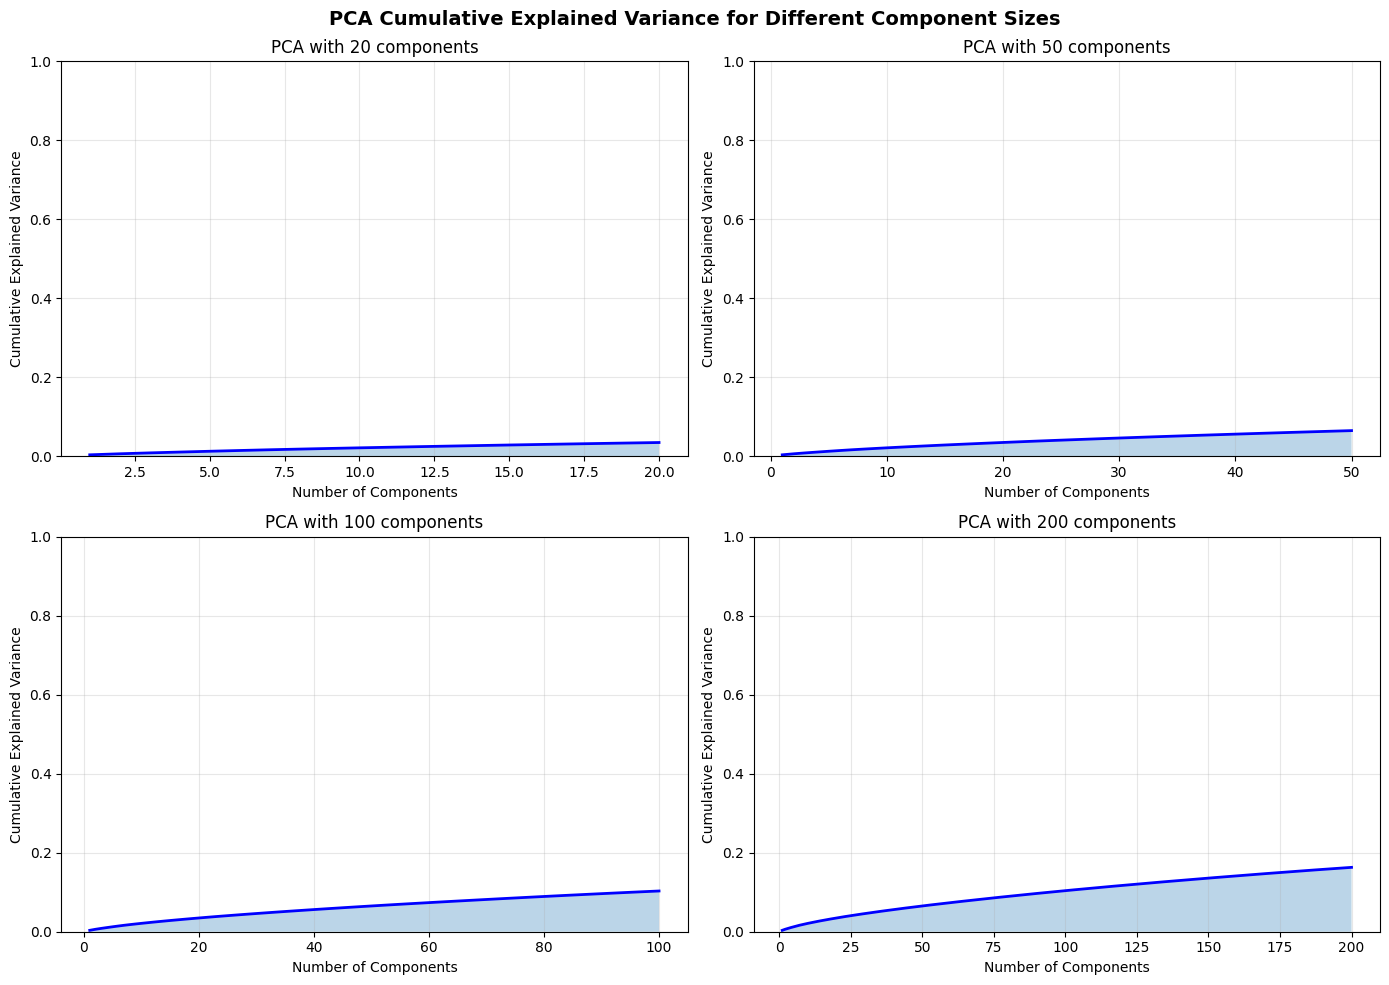

In [22]:
# Plot cumulative explained variance for best PCA (50 components)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('PCA Cumulative Explained Variance for Different Component Sizes', fontsize=14, fontweight='bold')

for idx, (n_comp, ax) in enumerate(zip(sorted(pca_results.keys()), axes.flatten())):
    result = pca_results[n_comp]
    cumsum_var = result['cumulative_variance']
    
    ax.plot(range(1, len(cumsum_var) + 1), cumsum_var, 'b-', linewidth=2)
    ax.fill_between(range(1, len(cumsum_var) + 1), cumsum_var, alpha=0.3)
    ax.set_xlabel('Number of Components')
    ax.set_ylabel('Cumulative Explained Variance')
    ax.set_title(f'PCA with {n_comp} components')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('../outputs/figures/pca_variance.png', dpi=300, bbox_inches='tight')
print("✓ Saved PCA variance plot to outputs/figures/pca_variance.png")
plt.show()

## Phase 4: K-Means Clustering on PCA-reduced Data

In [23]:
# Run K-Means for each PCA configuration
print("Running K-Means clustering for each PCA configuration...")
kmeans_results = {}

for n_comp in sorted(pca_results.keys()):
    X_pca = pca_results[n_comp]['X_pca']
    kmeans_result = run_kmeans(X_pca, n_clusters=2, random_state=42, n_init=10)
    kmeans_results[n_comp] = kmeans_result
    
    sil_score = kmeans_result['silhouette_score']
    print(f"n_components = {n_comp} | Silhouette Score: {sil_score:.4f}")

print("\n✓ K-Means clustering completed for all configurations")

Running K-Means clustering for each PCA configuration...
n_components = 20 | Silhouette Score: 0.0896
n_components = 50 | Silhouette Score: 0.0581
n_components = 100 | Silhouette Score: 0.0420
n_components = 200 | Silhouette Score: 0.0295

✓ K-Means clustering completed for all configurations


In [24]:
# Create comparison table
print("\nCLUSTERING EVALUATION TABLE:")
print("="*80)

clustering_eval = []
for n_comp in sorted(kmeans_results.keys()):
    sil_score = kmeans_results[n_comp]['silhouette_score']
    clustering_eval.append({
        'PCA Components': n_comp,
        'Silhouette Score': f"{sil_score:.4f}"
    })

clustering_table = pd.DataFrame(clustering_eval)
print(clustering_table.to_string(index=False))
print("="*80)


CLUSTERING EVALUATION TABLE:
 PCA Components Silhouette Score
             20           0.0896
             50           0.0581
            100           0.0420
            200           0.0295


## Phase 5: Cluster Analysis (Top Keywords)

In [ ]:
# Choose best configuration 
best_n_comp = 20
best_X_pca = pca_results[best_n_comp]['X_pca']
best_kmeans_result = kmeans_results[best_n_comp]
best_cluster_labels = best_kmeans_result['labels']

print(f"Using best PCA configuration: {best_n_comp} components")
print(f"Silhouette Score: {best_kmeans_result['silhouette_score']:.4f}")

Using best PCA configuration: 20 components
Silhouette Score: 0.0896


In [26]:
# Analyze clusters
cluster_analysis = analyze_clusters(
    X_tfidf,
    best_cluster_labels,
    tfidf_vectorizer,
    top_n=15
)

print("\nCLUSTER INTERPRETATION:")
print("="*80)

for cluster_id in [0, 1]:
    top_words = cluster_analysis[f'cluster_{cluster_id}']
    print(f"\nCluster {cluster_id} Top Keywords:")
    print(", ".join(top_words))
    
    # Try to interpret
    positive_indicators = ['excellent', 'amazing', 'wonderful', 'great', 'love', 'perfect', 'best', 'good', 'awesome']
    negative_indicators = ['terrible', 'awful', 'bad', 'worst', 'hate', 'boring', 'waste', 'poor', 'horrible']
    
    positive_count = sum(1 for w in top_words if w in positive_indicators)
    negative_count = sum(1 for w in top_words if w in negative_indicators)
    
    if positive_count > negative_count:
        print("→ Likely POSITIVE sentiment cluster")
    elif negative_count > positive_count:
        print("→ Likely NEGATIVE sentiment cluster")
    else:
        print("→ Mixed or unclear sentiment")

print("\n" + "="*80)


CLUSTER INTERPRETATION:

Cluster 0 Top Keywords:
great, performance, love, young, life, excellent, role, family, war, best, wonderful, series, play, man, beautiful
→ Likely POSITIVE sentiment cluster

Cluster 1 Top Keywords:
bad, like, dont, not, no, movie, worst, good, thing, im, think, acting, guy, didnt, know
→ Likely NEGATIVE sentiment cluster



In [27]:
# Check cluster distribution
print("\nCLUSTER DISTRIBUTION:")
print("="*80)
unique, counts = np.unique(best_cluster_labels, return_counts=True)
for cluster_id, count in zip(unique, counts):
    percentage = (count / len(best_cluster_labels)) * 100
    print(f"Cluster {cluster_id}: {count:6d} samples ({percentage:5.1f}%)")
print("="*80)


CLUSTER DISTRIBUTION:
Cluster 0:  30277 samples ( 60.6%)
Cluster 1:  19723 samples ( 39.4%)


## Phase 6: Save Clustering Results

In [28]:
# Save results
pca_results_df = pd.DataFrame(clustering_eval)
pca_results_df.to_csv('./outputs/pca_results.csv', index=False)
print("✓ Saved pca_results.csv")

# Save cluster labels and PCA transformed data
np.save('./outputs/best_cluster_labels.npy', best_cluster_labels)
np.save('./outputs/best_X_pca.npy', best_X_pca)
print("✓ Saved best_cluster_labels.npy")
print("✓ Saved best_X_pca.npy")

# Save cluster analysis
with open('./outputs/cluster_analysis.txt', 'w') as f:
    for cluster_id in [0, 1]:
        f.write(f"Cluster {cluster_id}: {', '.join(cluster_analysis[f'cluster_{cluster_id}'])}\n")
print("✓ Saved cluster_analysis.txt")

✓ Saved pca_results.csv
✓ Saved best_cluster_labels.npy
✓ Saved best_X_pca.npy
✓ Saved cluster_analysis.txt


In [29]:
print("\n" + "="*80)
print("PCA & K-MEANS PHASE COMPLETE!")
print("="*80)
print(f"Best PCA configuration: {best_n_comp} components")
print(f"Silhouette Score: {best_kmeans_result['silhouette_score']:.4f}")
print(f"Cluster distribution: {counts[0]} vs {counts[1]}")
print("\nNext step: Run Notebook 03 (Supervised Learning)")


PCA & K-MEANS PHASE COMPLETE!
Best PCA configuration: 20 components
Silhouette Score: 0.0896
Cluster distribution: 30277 vs 19723

Next step: Run Notebook 03 (Supervised Learning)
